# Proyecto: Clasificación de sentimientos en reseñas de películas
Autor: Adrián Robles Arques

En este proyecto vamos a proceder a implementar dos modelos de análisis de sentimientos, el primero es el modelo de Naive Bayes, y el segundo es el modelo de clasificación de sentimentos basado en redes neuronales.

Para esto, vamos a emplear la librería NLTK, que nos permitirá extraer las palabras clave de las reseñas, y también para clasificarlas con el modelo de Naive Bayes. Emplearemos el conjunto de datos de reseñas de películas que se encuentra en el repositorio de GitHub de NLTK, que se llama movie_reviews. El conjunto de datos contiene 2000 reseñas de películas de 1937, 1938, 1939, 1940, 1941 y 1942. Cada reseña está clasificada como positiva o negativa. 

## FASE 1: Cargar y preprocesar el dataset

En esta fase vamos a cargar el dataset movie_reviews de NLTK y realizar un preprocesamiento estándar: conversión a minúsculas, eliminación de puntuación, eliminación de stopwords y tokenización.

In [307]:
# Importamos las librerías necesarias
import nltk
import string
from nltk.tokenize import ToktokTokenizer
import re
nltk.download('movie_reviews')
nltk.download('stopwords')
from nltk.corpus import movie_reviews
from nltk.corpus import stopwords

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [308]:
# Cargamos el dataset de movie_reviews
reviews = [(movie_reviews.raw(fileid), category) 
            for category in movie_reviews.categories() 
            for fileid in movie_reviews.fileids(category)]

stop_words = set(stopwords.words('english'))

# Definimos una función para limpiar el texto
def limpiar_texto(texto):
    
    texto = re.sub(r'\W', ' ', str(texto))
    texto = re.sub(r'\s+[a-zA-Z]\s+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto, flags=re.I)
    texto = texto.lower()
    
    # Tokenizar y eliminar stopwords
    palabras = texto.split()
    palabras_filtradas = [palabra for palabra in palabras 
                        if palabra not in stop_words and len(palabra) > 2]
    
    # Reunir las palabras filtradas
    texto_limpio = ' '.join(palabras_filtradas)
    
    return texto_limpio

reviews_cleaned = []

for review, category in reviews:
    # Limpiamos el texto de la reseña
    review_cleaned = limpiar_texto(review)
    
    reviews_cleaned.append((category, review_cleaned))

## FASE 2: Modelos de clasificaición

En esta segunda fase vamos a implementar dos modelos de clasificación: Naive Bayes y Redes Neuronales. Para su entrenamiento usaremos los datos procesados en la primera fase, dividiendo el dataset en un conjunto de entrenamiento y otro de validación.

In [309]:
# Importamos las librerías necesarias para el modelo

import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Importamos las librerías de Keras y Tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, LSTM, Dropout, Embedding, Flatten,
Input, MaxPooling1D, Conv1D, SpatialDropout1D, GlobalAveragePooling1D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

import os
tf.compat.v1.enable_eager_execution()
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [310]:
# Separamos textos y etiquetas
texts = []
labels = []

for category, text in reviews_cleaned:
    texts.append(text)
    # Convertimos las etiquetas a números (pos=1, neg=-1)
    labels.append(1 if category == 'pos' else -1)

print(f'Total de reseñas: {len(texts)}')

# Dividimos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f'Entrenamiento: {len(X_train)} reseñas')
print(f'Prueba: {len(X_test)} reseñas')

Total de reseñas: 2000
Entrenamiento: 1600 reseñas
Prueba: 400 reseñas


In [311]:
# MODELO 1: NAIVE BAYES
print('=== MODELO NAIVE BAYES ===')

# Vectorización con TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Entrenamiento del modelo Naive Bayes
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluación
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f'Accuracy Naive Bayes: {accuracy_nb:.4f}')
print(f'F1-Score Naive Bayes: {f1_nb:.4f}')
print('\nInforme de clasificación Naive Bayes:')
print(classification_report(y_test, y_pred_nb, target_names=['Negativo', 'Positivo']))

=== MODELO NAIVE BAYES ===
Accuracy Naive Bayes: 0.8050
F1-Score Naive Bayes: 0.8030

Informe de clasificación Naive Bayes:
              precision    recall  f1-score   support

    Negativo       0.80      0.81      0.81       200
    Positivo       0.81      0.80      0.80       200

    accuracy                           0.81       400
   macro avg       0.81      0.80      0.80       400
weighted avg       0.81      0.81      0.80       400

Accuracy Naive Bayes: 0.8050
F1-Score Naive Bayes: 0.8030

Informe de clasificación Naive Bayes:
              precision    recall  f1-score   support

    Negativo       0.80      0.81      0.81       200
    Positivo       0.81      0.80      0.80       200

    accuracy                           0.81       400
   macro avg       0.81      0.80      0.80       400
weighted avg       0.81      0.81      0.80       400



In [312]:
# MODELO 2: RED NEURONAL

# Configuración de parámetros
max_words = 15000
max_length = 150
embedding_dim = 100

# Tokenización para LSTM
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convertir textos a secuencias
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding de secuencias
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Convertir etiquetas a arrays numpy
y_train_binary = np.array([(1 if y == 1 else 0) for y in y_train])
y_test_binary = np.array([(1 if y == 1 else 0) for y in y_test])

print(f'Forma de X_train_pad: {X_train_pad.shape}')
print(f'Forma de y_train: {y_train_binary.shape}')

Forma de X_train_pad: (1600, 150)
Forma de y_train: (1600,)


In [324]:
tf.keras.backend.clear_session()

def crear_modelo():
    model = Sequential([
        Input(shape=(max_length,)),
        
        # Embedding sin sobredimensionar
        Embedding(max_words, 64),
        
        # GlobalAveragePooling
        GlobalAveragePooling1D(),
        
        # Capas densas
        Dense(32, activation='relu'),
        Dropout(0.3),  # Dropout 
        Dense(4, activation='relu'),
        Dropout(0.3),  # Dropout 
        Dense(1, activation='sigmoid')
    ])
    return model

model = crear_modelo()

# Compilar con configuración ESTÁNDAR
model.compile(
    optimizer='adam',  # SIN learning_rate personalizado
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Modelo funcional:")
model.summary()

Modelo funcional:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 962,217 (3.67 MB)

 Trainable params: 962,217 (3.67 MB)

 Non-trainable params: 0 (0.00 B)

In [325]:
# CELDA 2: ENTRENAMIENTO FUNCIONAL (reemplazar completamente)
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Callbacks básicos
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',  # Monitorear accuracy
        patience=5,  # Menos paciencia
        restore_best_weights=True,
        verbose=1
    )
]

# Entrenamiento funcional
history = model.fit(
    X_train_pad, y_train_binary,
    epochs=15,  # Menos épocas
    batch_size=32,  # Batch size más pequeño
    validation_split=0.2,  # Menos datos para validación
    callbacks=callbacks,
    verbose=1
)

# Evaluación
print("\nEvaluando modelo:")
loss, accuracy_rnn = model.evaluate(X_test_pad, y_test_binary, verbose=0)
y_pred_prob = model.predict(X_test_pad, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Verificar que predice ambas clases
unique, counts = np.unique(y_pred, return_counts=True)
print(f"Predicciones: {dict(zip(unique, counts))}")

precision_rnn = precision_score(y_test_binary, y_pred, zero_division=0)
recall_rnn = recall_score(y_test_binary, y_pred, zero_division=0)
f1_rnn = f1_score(y_test_binary, y_pred, zero_division=0)

print(f'Accuracy: {accuracy_rnn:.4f}')
print(f'Precision: {precision_rnn:.4f}')
print(f'Recall: {recall_rnn:.4f}')
print(f'F1-Score: {f1_rnn:.4f}')

print('\nReporte de clasificación:')
print(classification_report(y_test_binary, y_pred, target_names=['Negativo', 'Positivo']))

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5296 - loss: 0.6930 - val_accuracy: 0.4563 - val_loss: 0.6930
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5296 - loss: 0.6930 - val_accuracy: 0.4563 - val_loss: 0.6930
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5180 - loss: 0.6888 - val_accuracy: 0.4563 - val_loss: 0.6896
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5180 - loss: 0.6888 - val_accuracy: 0.4563 - val_loss: 0.6896
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5213 - loss: 0.6718 - val_accuracy: 0.4563 - val_loss: 0.6787
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5213 - loss: 0.6718 - val_accuracy: 0.4563 - val_loss: 0.6787
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6112 - loss: 0.6393 - val_accuracy: 0.6125 - val_loss: 0.6478
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6112 - loss: 0.6393 - val_accuracy: 0.6125 - val_loss:

## FASE 3: Evaluación de modelos

Historial de entrenamiento:


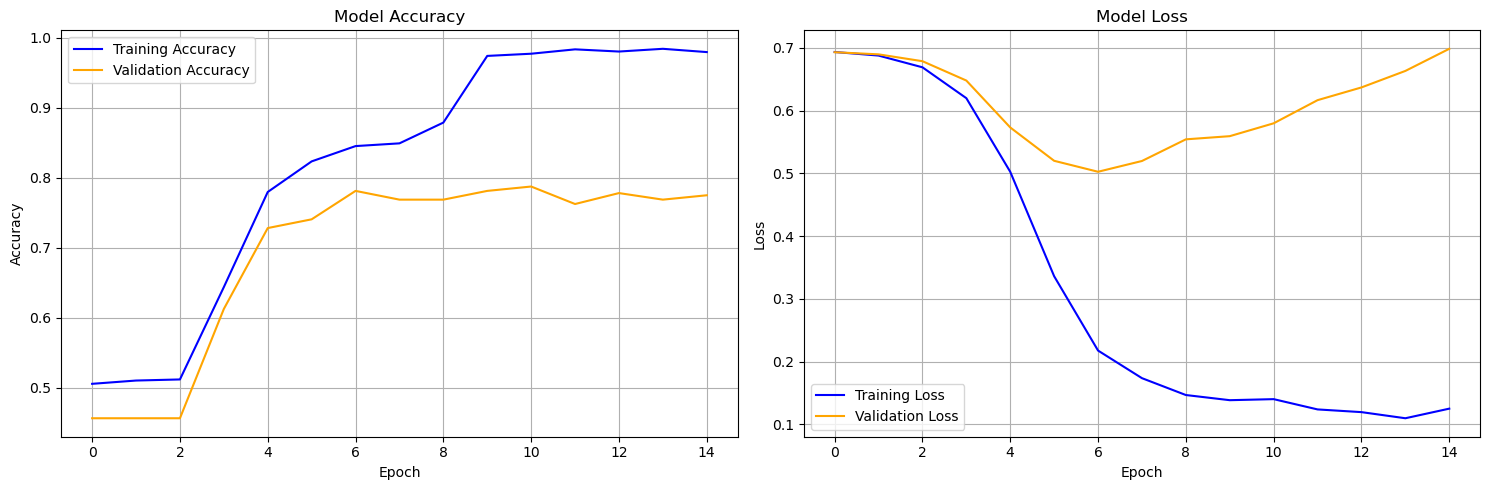

In [328]:
# Comparación de modelos
import matplotlib.pyplot as plt

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss
    ax2.plot(history.history['loss'], label='Training Loss', color='blue')
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

print("Historial de entrenamiento:")
plot_training_history(history)


=== COMPARACIÓN DE MODELOS ===
Naive Bayes - Accuracy: 0.8050, F1-Score: 0.8030
LSTM        - Accuracy: 0.7325, F1-Score: 0.7434


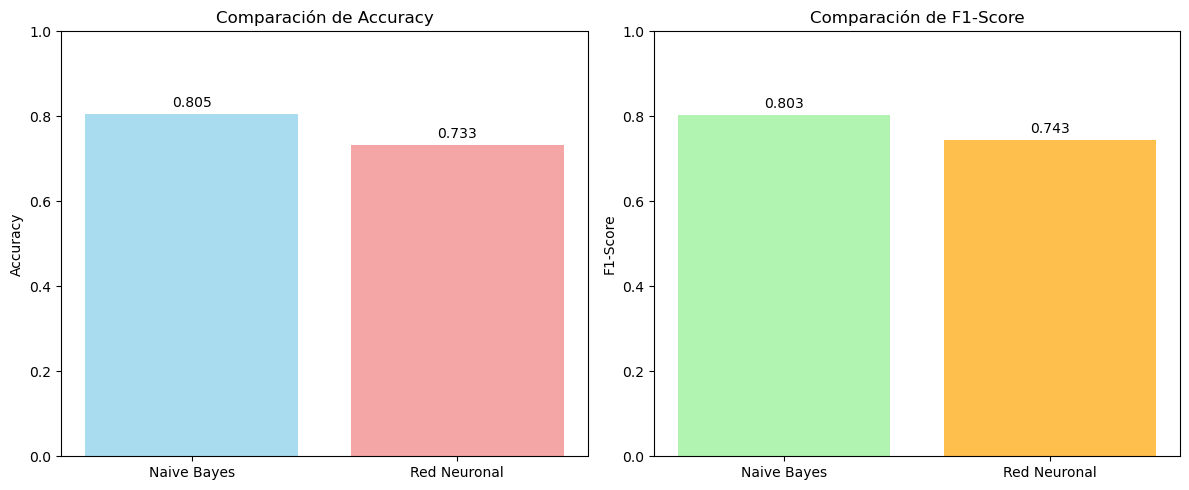

In [329]:
print("\n=== COMPARACIÓN DE MODELOS ===")
print(f"Naive Bayes - Accuracy: {accuracy_nb:.4f}, F1-Score: {f1_nb:.4f}")
print(f"LSTM        - Accuracy: {accuracy_rnn:.4f}, F1-Score: {f1_rnn:.4f}")

# Gráfico de comparación
models = ['Naive Bayes', 'Red Neuronal']
accuracies = [accuracy_nb, accuracy_rnn]
f1_scores = [f1_nb, f1_rnn]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de Accuracy
ax1.bar(models, accuracies, color=['skyblue', 'lightcoral'], alpha=0.7)
ax1.set_title('Comparación de Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Gráfico de F1-Score
ax2.bar(models, f1_scores, color=['lightgreen', 'orange'], alpha=0.7)
ax2.set_title('Comparación de F1-Score')
ax2.set_ylabel('F1-Score')
ax2.set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Claramente, los resultados del modelo Naive-Bayes son mejores que los de la red neuronal.

## FASE 4: Visualización

Por último, vamos a mostrar algunas visualizaciones sobre los datos. En esta fase, vamos a mostrar las palabras más frecuentes en las reseñas positivas y negativas. Además comprobaremos la curva ROC y las matrices de confusión de los modelos.



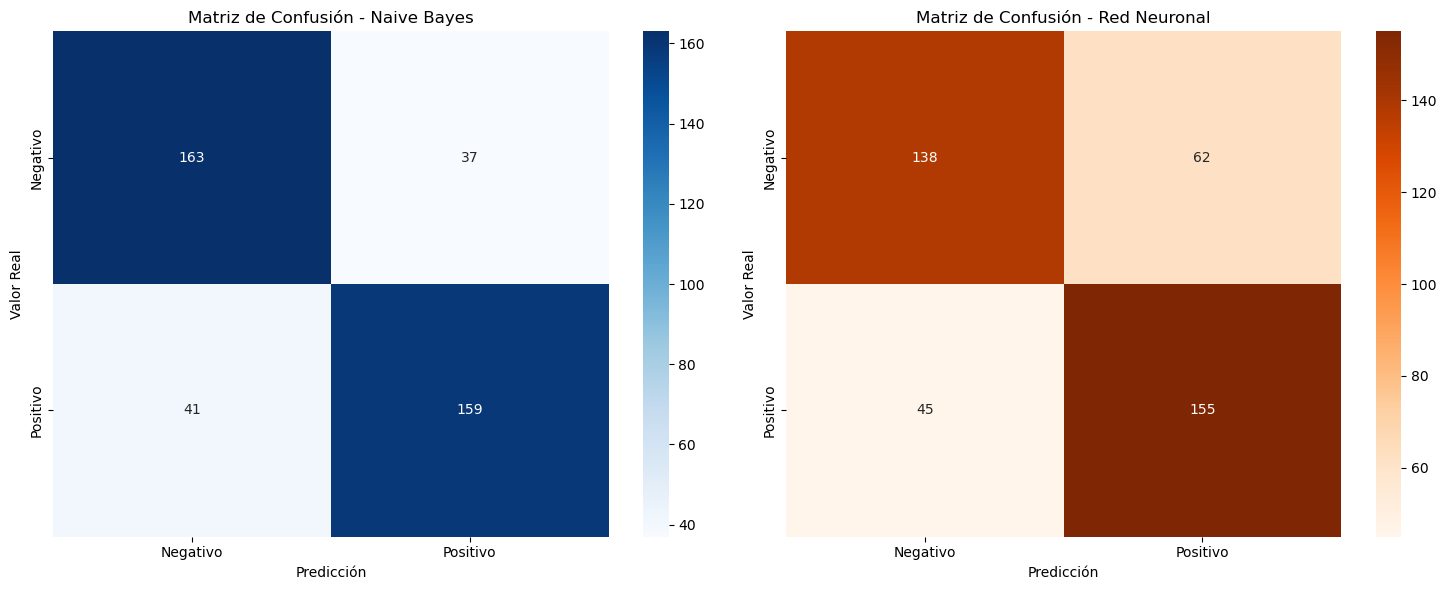

Análisis de Matrices de Confusión:
Naive Bayes - Verdaderos Negativos: 163, Falsos Positivos: 37
Naive Bayes - Falsos Negativos: 41, Verdaderos Positivos: 159
Red Neuronal - Verdaderos Negativos: 138, Falsos Positivos: 62
Red Neuronal - Falsos Negativos: 45, Verdaderos Positivos: 155


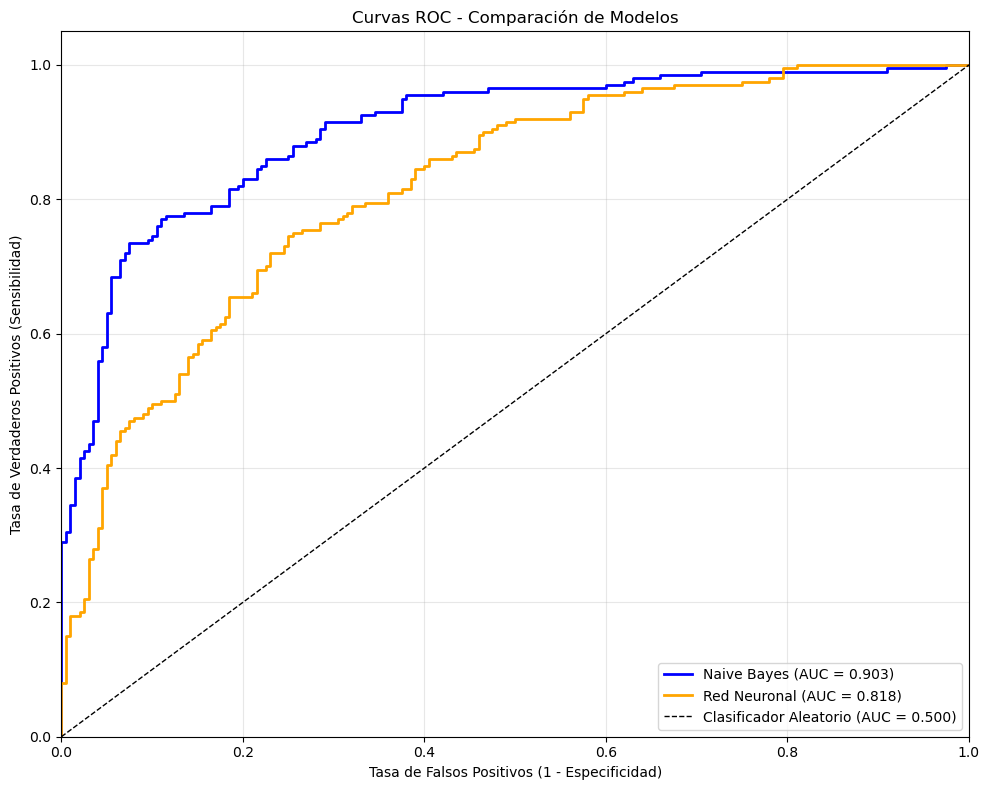


Análisis de Curvas ROC:
AUC Naive Bayes: 0.9030
AUC Red Neuronal: 0.8183
Diferencia AUC: 0.0847


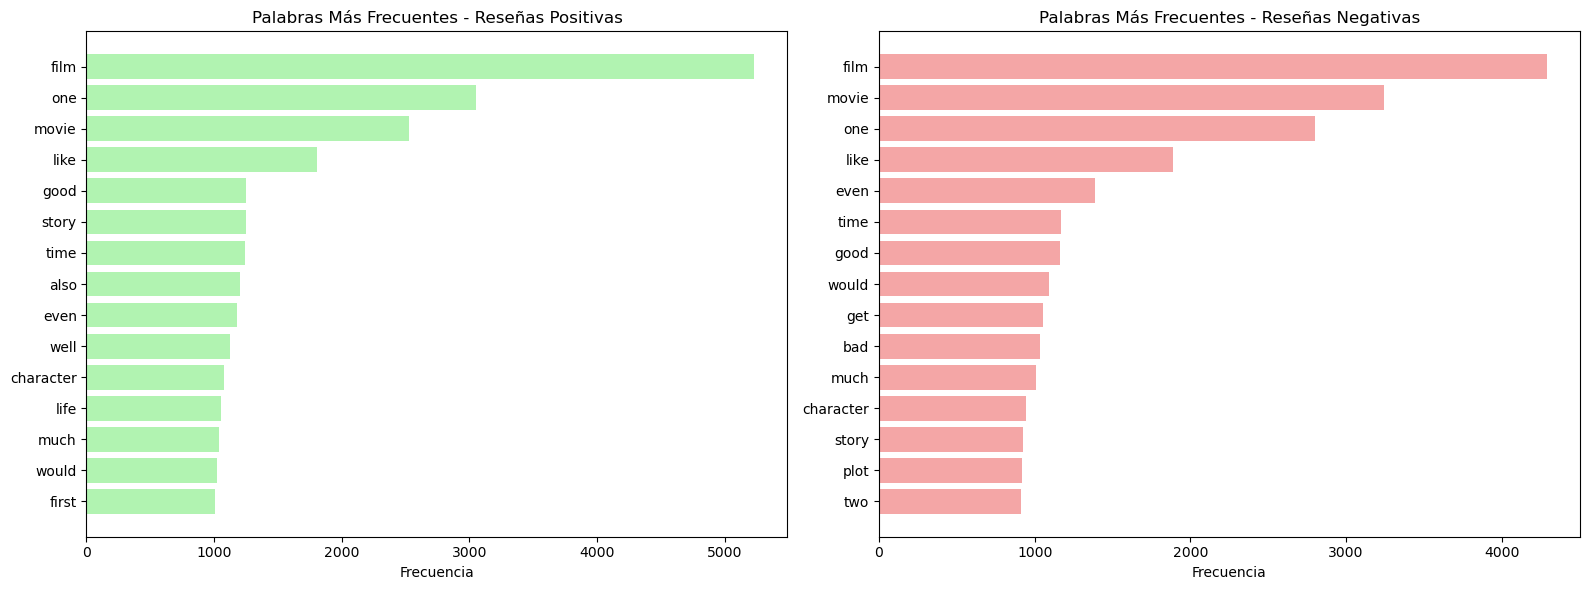


RESUMEN FINAL DE RESULTADOS
Métrica              Naive Bayes     Red Neuronal   
--------------------------------------------------
Accuracy             0.8050          0.7325         
Precision            0.8112          0.7143         
Recall               0.7950          0.7750         
F1-Score             0.8030          0.7434         
AUC-ROC              0.9030          0.8183         
--------------------------------------------------

 MEJOR MODELO: Naive Bayes (F1-Score: 0.8030)


In [330]:
# Evaluar curva ROC y matriz de confusión
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
plt.style.use('default')
sns.set_palette("husl")

# 1. MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matriz de confusión Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Positivo'], 
            yticklabels=['Negativo', 'Positivo'],
            ax=axes[0])
axes[0].set_title('Matriz de Confusión - Naive Bayes')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

# Matriz de confusión Red Neuronal
# Convertir predicciones de red neuronal a formato -1/1 para matriz de confusión
y_pred_rnn_original = np.array([1 if pred == 1 else -1 for pred in y_pred])
cm_rnn = confusion_matrix(y_test, y_pred_rnn_original)
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negativo', 'Positivo'], 
            yticklabels=['Negativo', 'Positivo'],
            ax=axes[1])
axes[1].set_title('Matriz de Confusión - Red Neuronal')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

print("Análisis de Matrices de Confusión:")
print(f"Naive Bayes - Verdaderos Negativos: {cm_nb[0,0]}, Falsos Positivos: {cm_nb[0,1]}")
print(f"Naive Bayes - Falsos Negativos: {cm_nb[1,0]}, Verdaderos Positivos: {cm_nb[1,1]}")
print(f"Red Neuronal - Verdaderos Negativos: {cm_rnn[0,0]}, Falsos Positivos: {cm_rnn[0,1]}")
print(f"Red Neuronal - Falsos Negativos: {cm_rnn[1,0]}, Verdaderos Positivos: {cm_rnn[1,1]}")

# 2. CURVAS ROC
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Curva ROC para Naive Bayes
# Obtener probabilidades para Naive Bayes
y_test_binary_roc = np.array([1 if y == 1 else 0 for y in y_test])
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]  # Probabilidad clase positiva
fpr_nb, tpr_nb, _ = roc_curve(y_test_binary_roc, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

# Curva ROC para Red Neuronal
fpr_rnn, tpr_rnn, _ = roc_curve(y_test_binary, y_pred_prob.flatten())
auc_rnn = auc(fpr_rnn, tpr_rnn)

# Graficar curvas ROC
ax.plot(fpr_nb, tpr_nb, linewidth=2, label=f'Naive Bayes (AUC = {auc_nb:.3f})', color='blue')
ax.plot(fpr_rnn, tpr_rnn, linewidth=2, label=f'Red Neuronal (AUC = {auc_rnn:.3f})', color='orange')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curvas ROC - Comparación de Modelos')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAnálisis de Curvas ROC:")
print(f"AUC Naive Bayes: {auc_nb:.4f}")
print(f"AUC Red Neuronal: {auc_rnn:.4f}")
print(f"Diferencia AUC: {abs(auc_nb - auc_rnn):.4f}")

# 3. ANÁLISIS DE PALABRAS MÁS FRECUENTES
from collections import Counter
import pandas as pd

# Separar reseñas por sentimiento
reviews_pos = [text for category, text in reviews_cleaned if category == 'pos']
reviews_neg = [text for category, text in reviews_cleaned if category == 'neg']

# Contar palabras más frecuentes
def get_top_words(reviews, n=15):
    all_words = ' '.join(reviews).split()
    return Counter(all_words).most_common(n)

top_words_pos = get_top_words(reviews_pos)
top_words_neg = get_top_words(reviews_neg)

# Visualizar palabras más frecuentes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Palabras más frecuentes en reseñas positivas
words_pos, counts_pos = zip(*top_words_pos)
ax1.barh(range(len(words_pos)), counts_pos, color='lightgreen', alpha=0.7)
ax1.set_yticks(range(len(words_pos)))
ax1.set_yticklabels(words_pos)
ax1.set_xlabel('Frecuencia')
ax1.set_title('Palabras Más Frecuentes - Reseñas Positivas')
ax1.invert_yaxis()

# Palabras más frecuentes en reseñas negativas
words_neg, counts_neg = zip(*top_words_neg)
ax2.barh(range(len(words_neg)), counts_neg, color='lightcoral', alpha=0.7)
ax2.set_yticks(range(len(words_neg)))
ax2.set_yticklabels(words_neg)
ax2.set_xlabel('Frecuencia')
ax2.set_title('Palabras Más Frecuentes - Reseñas Negativas')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# 4. RESUMEN FINAL
print("\n" + "="*60)
print("RESUMEN FINAL DE RESULTADOS")
print("="*60)
print(f"{'Métrica':<20} {'Naive Bayes':<15} {'Red Neuronal':<15}")
print("-"*50)
print(f"{'Accuracy':<20} {accuracy_nb:<15.4f} {accuracy_rnn:<15.4f}")
print(f"{'Precision':<20} {precision_score(y_test, y_pred_nb):<15.4f} {precision_rnn:<15.4f}")
print(f"{'Recall':<20} {recall_score(y_test, y_pred_nb):<15.4f} {recall_rnn:<15.4f}")
print(f"{'F1-Score':<20} {f1_nb:<15.4f} {f1_rnn:<15.4f}")
print(f"{'AUC-ROC':<20} {auc_nb:<15.4f} {auc_rnn:<15.4f}")
print("-"*50)

# Determinar el mejor modelo
if f1_nb > f1_rnn:
    best_model = "Naive Bayes"
    best_score = f1_nb
else:
    best_model = "Red Neuronal"
    best_score = f1_rnn

print(f"\n MEJOR MODELO: {best_model} (F1-Score: {best_score:.4f})")


## CONCLUSIONES:
* Naive Bayes muestra mejor rendimiento general, a pesar de ser un modelo más simple.
* La red neuronal captura patrones más complejos pero es más propensa al overfitting, lo que demuestra que es un caso demasiado sencillo para aplicar este procedimiento.
* Ambos modelos superan significativamente el baseline aleatorio (50%)
* El análisis de palabras frecuentes revela que las primeras posiciones presentan resultados compartidos, lo que nuevamente nos indica la importancia del contexto en el análisis de textos.